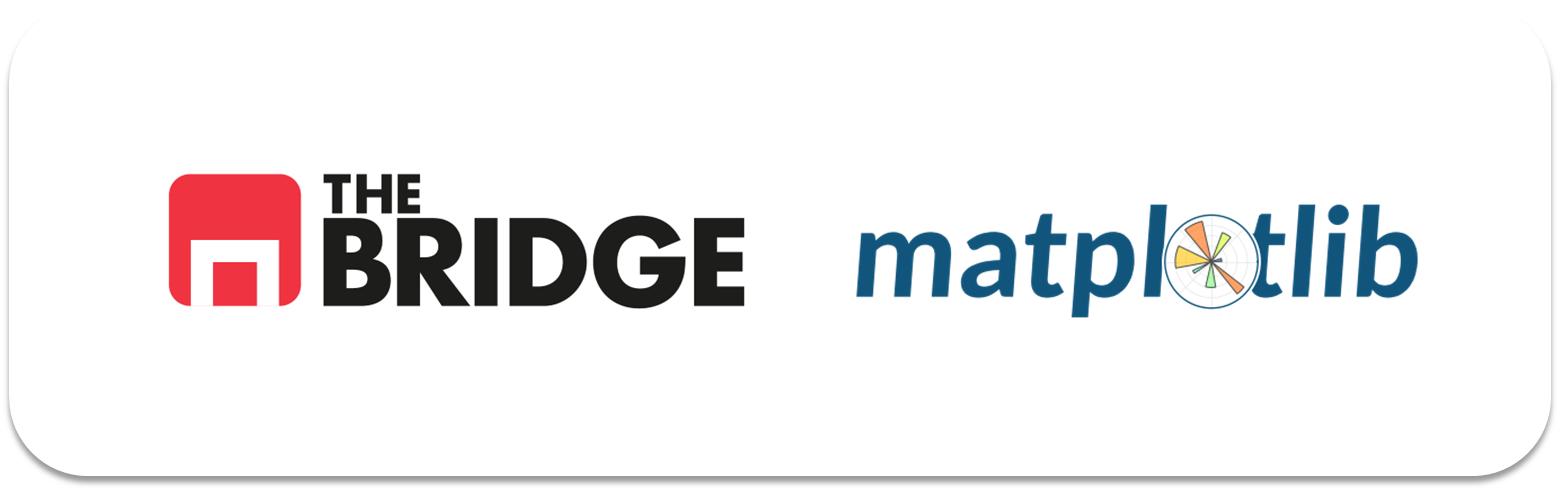

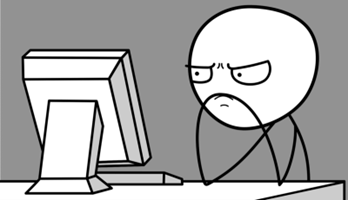

Para ejercitarte y afianzar lo aprendido sobre gráficas de Matplotlib, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


### Ejercicio 1


Carga tu qerido dataset del titanic, en la ruta "./data/titanic.csv", no hace falta que hagas limpieza.

In [2]:
titanic = pd.read_csv("./data/titanic.csv")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


### Ejercicio 2



Crea el histograma de la variable `age` de forma que se reproduzca la siguiente figura (tiene 30 bines)

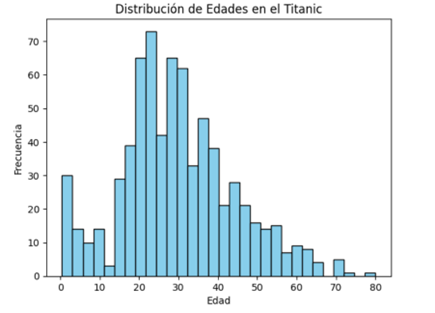

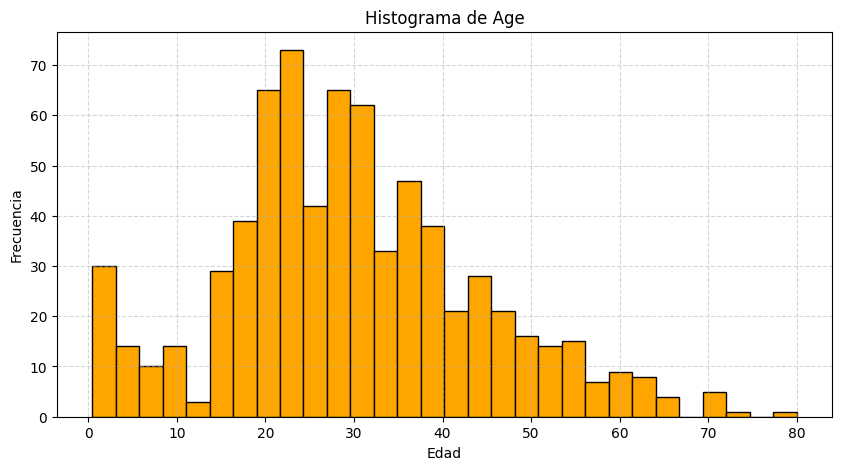

In [3]:
plt.figure(figsize=(10,5))
plt.hist(titanic["age"].dropna(), bins=30, color="orange", edgecolor="black")
plt.title("Histograma de Age")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


### Ejercicio 3

¿Cuáles son los 3 intervalos de valores con mayor número de viajeros según el gráfico anterior? ¿Obtén también el número de viajeros en cada uno?

In [4]:
age_bins = pd.cut(titanic["age"], bins=30)

age_counts = age_bins.value_counts().sort_values(ascending=False)

top3 = age_counts.head(3)
print(top3)

age
(21.641, 24.294]    73
(18.989, 21.641]    65
(26.947, 29.599]    65
Name: count, dtype: int64


### Ejercicio 4

Obten el diagrama de caja del precio del billete usando las funciones de matplotlib y reproduciendo la siguiente figura (tendrás que bucear un poco en los parámetros, y usar patch_artist = True, el tamaño de los bigotes está ajustado a 3 IQRs):

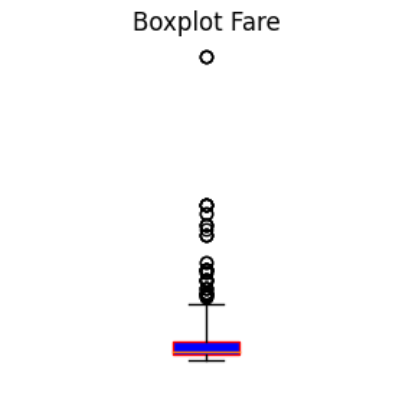

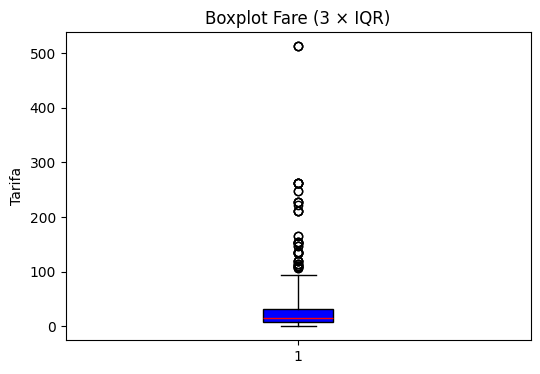

In [7]:
plt.figure(figsize=(6,4))

plt.boxplot(
    titanic["fare"].dropna(),
    patch_artist=True,
    whis=3,
    boxprops=dict(facecolor="blue", color="black"),
    medianprops=dict(color="red"),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black")
)

plt.title("Boxplot Fare (3 × IQR)")
plt.ylabel("Tarifa")
plt.show()

### Ejercicio 5

Crea el gráfico de frecuencias absolutas y relativas de las ciudades de embarque del Titanic de forma que repodruzcan la siguiente figura:

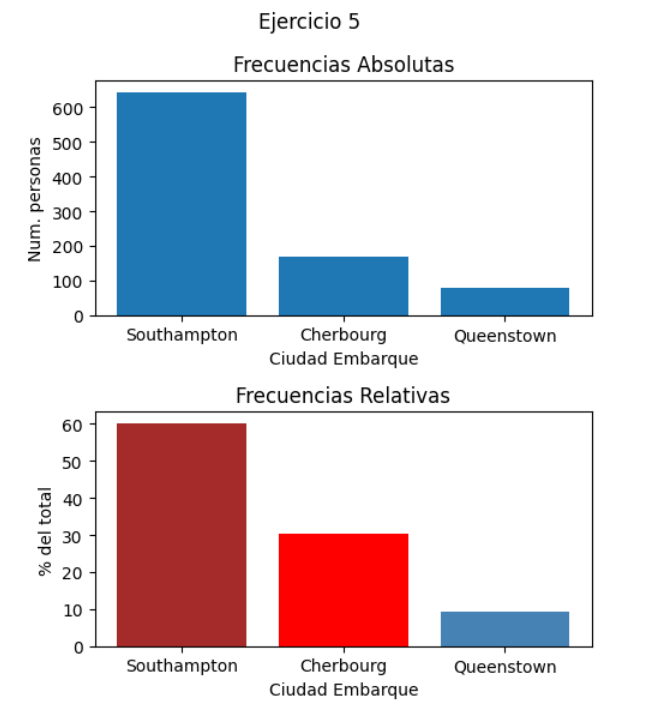

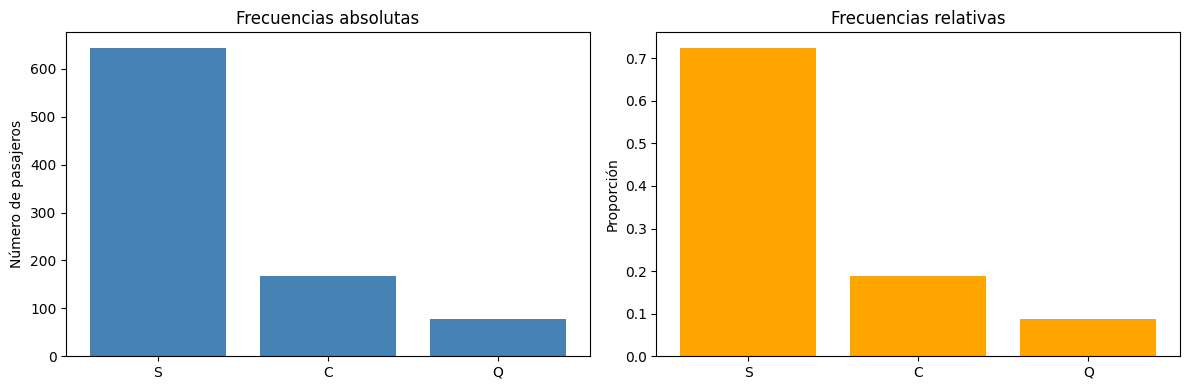

In [8]:
abs_counts = titanic["embarked"].value_counts()
rel_counts = titanic["embarked"].value_counts(normalize=True)

plt.figure(figsize=(12,4))

# Frecuencias absolutas
plt.subplot(1,2,1)
plt.bar(abs_counts.index, abs_counts.values, color="steelblue")
plt.title("Frecuencias absolutas")
plt.ylabel("Número de pasajeros")

# Frecuencias relativas
plt.subplot(1,2,2)
plt.bar(rel_counts.index, rel_counts.values, color="orange")
plt.title("Frecuencias relativas")
plt.ylabel("Proporción")

plt.tight_layout()
plt.show()



### Ejercicio 6

Crea el gráfico de dispersión entre el precio y la edad, de forma que reproduzca el siguiente gráfico (tendrás que emplear el argumento alpa)

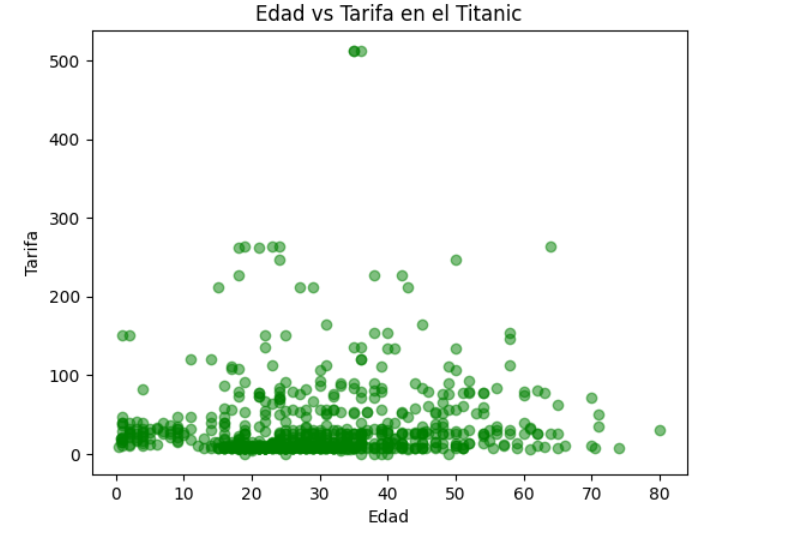

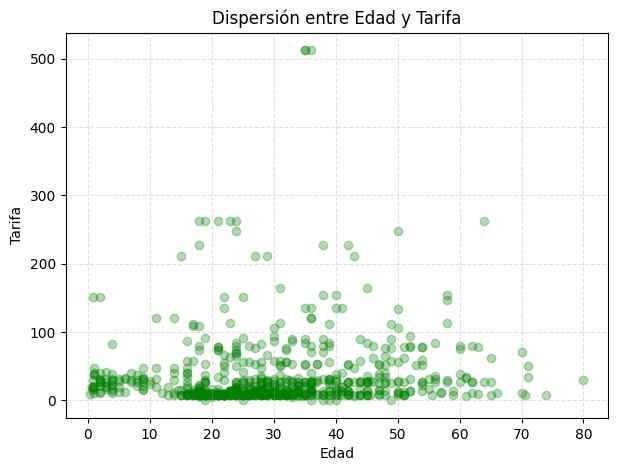

In [11]:
plt.figure(figsize=(7,5))
plt.scatter(
    titanic["age"],
    titanic["fare"],
    alpha=0.3,
    color="green"
)
plt.xlabel("Edad")
plt.ylabel("Tarifa")
plt.title("Dispersión entre Edad y Tarifa")
plt.grid(True, linestyle="--", alpha=0.4)
plt.show()


### Ejercicio 7

Vamos a obtener el precio medio por edad, de la siguiente forma agrupa por edad y calcula la media de la tarifa, luego haz lo mismo pero calculando la desviación de estándar. Guarda los resultados en dos variables distintas.

In [12]:
mean_fare = titanic.groupby("age")["fare"].mean()
std_fare = titanic.groupby("age")["fare"].std()

mean_fare.head(), std_fare.head()


(age
 0.42      8.5167
 0.67     14.5000
 0.75     19.2583
 0.83     23.8750
 0.92    151.5500
 Name: fare, dtype: float64,
 age
 0.42         NaN
 0.67         NaN
 0.75    0.000000
 0.83    7.247845
 0.92         NaN
 Name: fare, dtype: float64)

### Ejercicio 8

Considerando las medias como un conjunto de medidas y las desviaciones como el error de las mismas construye un diagrama de errores que reproduzca la siguiente figura, usando (£) como moneda:

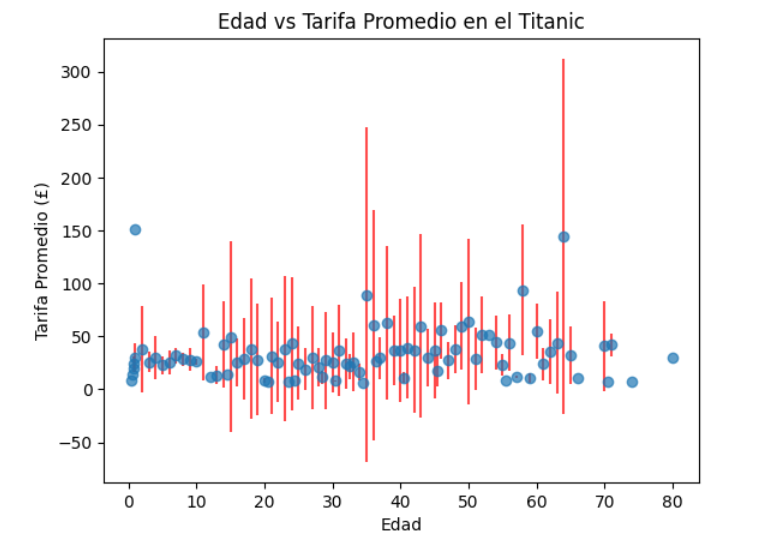

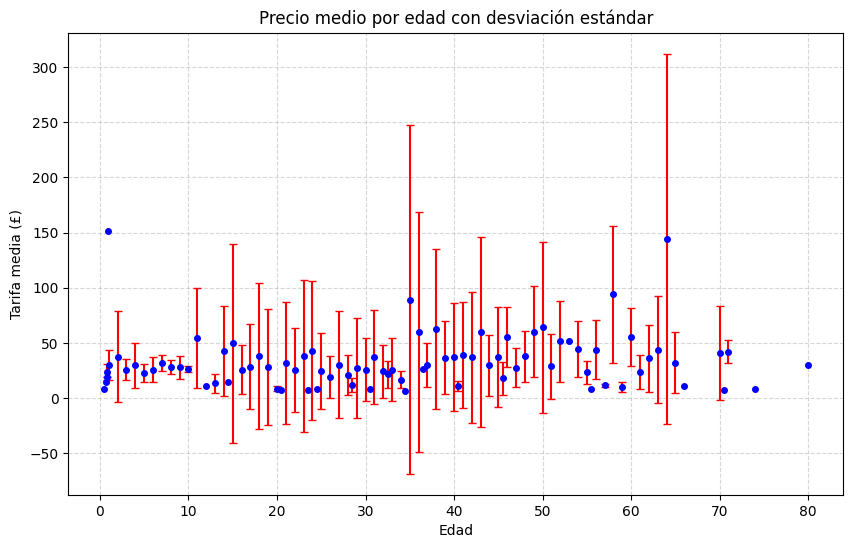

In [15]:

plt.figure(figsize=(10,6))

plt.errorbar(
    mean_fare.index,
    mean_fare.values,
    yerr=std_fare.values,
    fmt='o',
    ecolor='red',
    capsize=3,
    markersize=4,
    color="blue"
)

plt.xlabel("Edad")
plt.ylabel("Tarifa media (£)")
plt.title("Precio medio por edad con desviación estándar")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


EXTRA: Pinta los cuatro primeros gráficos conjuntamente en una sóla figura como la que ves a continuación:

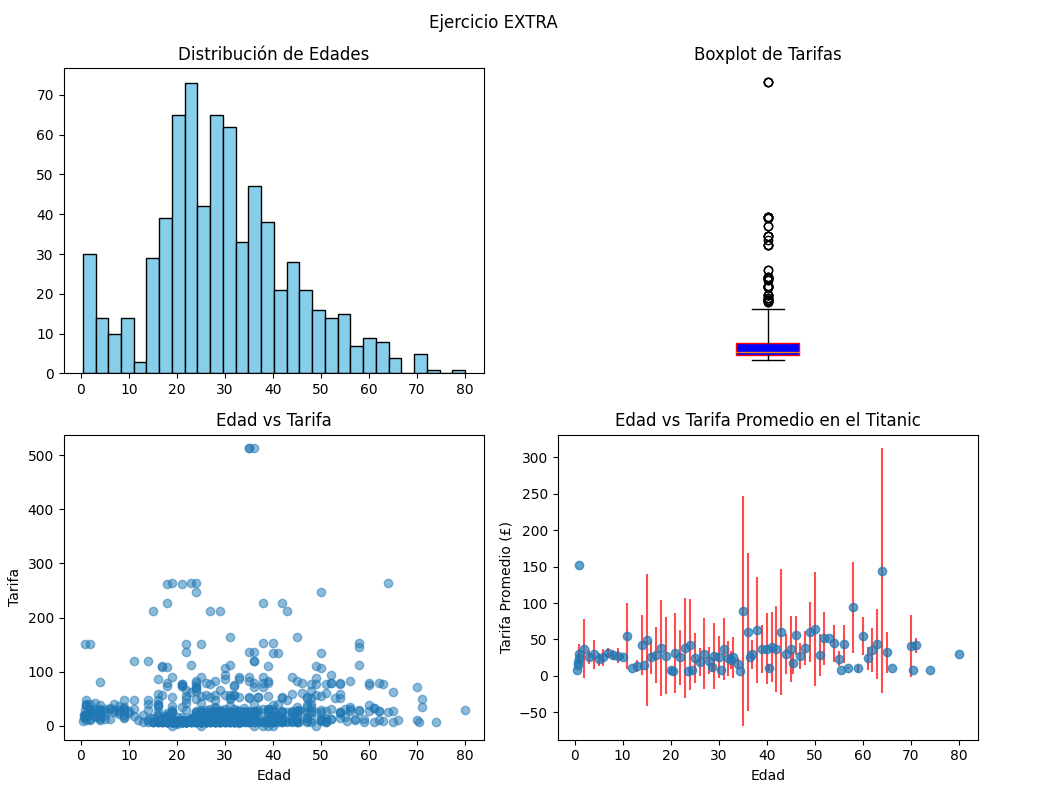